<a href="https://colab.research.google.com/github/JoseLLoredoHdz/mineria/blob/main/Clasificaci%C3%B3n_de_D%C3%ADgitos_Manuscritos_178446.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

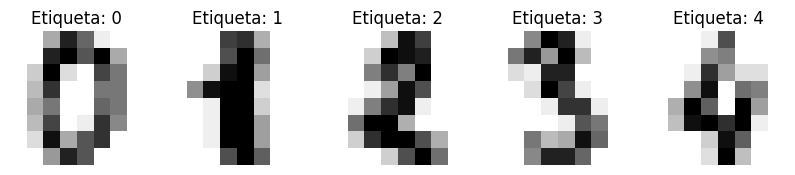

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Cargar el dataset
digits = datasets.load_digits()

# Visualización de las primeras imágenes
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f'Etiqueta: {label}')

# Preparar los datos (aplanar las imágenes de 8x8 a un vector de 64)
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.2, shuffle=True, random_state=42
)


Reporte para KNN (k=5):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       0.98      1.00      0.99        46
           5       0.98      0.96      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.95      0.95      0.95        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360

Exactitud (Accuracy): 0.9861
------------------------------

Reporte para SVM (RBF):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.0

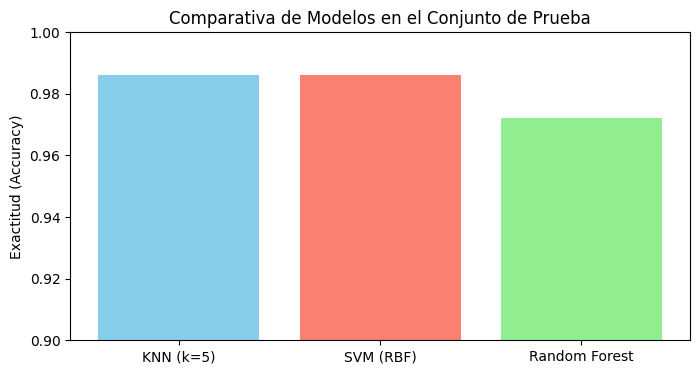

In [3]:
# Inicializar modelos
models = {
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel='rbf', gamma='scale', C=1.0),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Entrenar y evaluar
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\nReporte para {name}:")
    print(classification_report(y_test, preds))
    print(f"Exactitud (Accuracy): {acc:.4f}")
    print("-" * 30)

# Comparación rápida
plt.figure(figsize=(8, 4))
plt.bar(results.keys(), results.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.ylabel('Exactitud (Accuracy)')
plt.title('Comparativa de Modelos en el Conjunto de Prueba')
plt.ylim(0.9, 1.0)
plt.show()

In [4]:
# dígitos manuales ( 1, 0, 7)
# Los valores van de 0 a 16
digito_1 = np.array([
    [0,0,0,1,16,0,0,0],
    [0,0,0,1,16,0,0,0],
    [0,0,0,1,16,0,0,0],
    [0,0,0,1,16,0,0,0],
    [0,0,0,1,16,0,0,0],
    [0,0,0,1,16,0,0,0],
    [0,0,0,1,16,0,0,0],
    [0,0,0,1,16,0,0,0]
])

digito_0 = np.array([
    [0,0,12,16,16,12,0,0],
    [0,12,16,5,5,16,12,0],
    [0,16,8,0,0,8,16,0],
    [0,16,8,0,0,8,16,0],
    [0,16,8,0,0,8,16,0],
    [0,16,8,0,0,8,16,0],
    [0,12,16,5,5,16,12,0],
    [0,0,12,16,16,12,0,0]
])

digito_7 = np.array([
    [0,16,16,16,16,16,16,0],
    [0,0,0,0,0,2,16,0],
    [0,0,0,0,0,8,16,0],
    [0,0,0,0,4,16,2,0],
    [0,0,0,2,16,6,0,0],
    [0,0,0,14,8,0,0,0],
    [0,0,0,16,2,0,0,0],
    [0,0,0,12,0,0,0,0]
])

mis_digitos = [digito_1, digito_0, digito_7]
etiquetas_reales = [1, 0, 7]

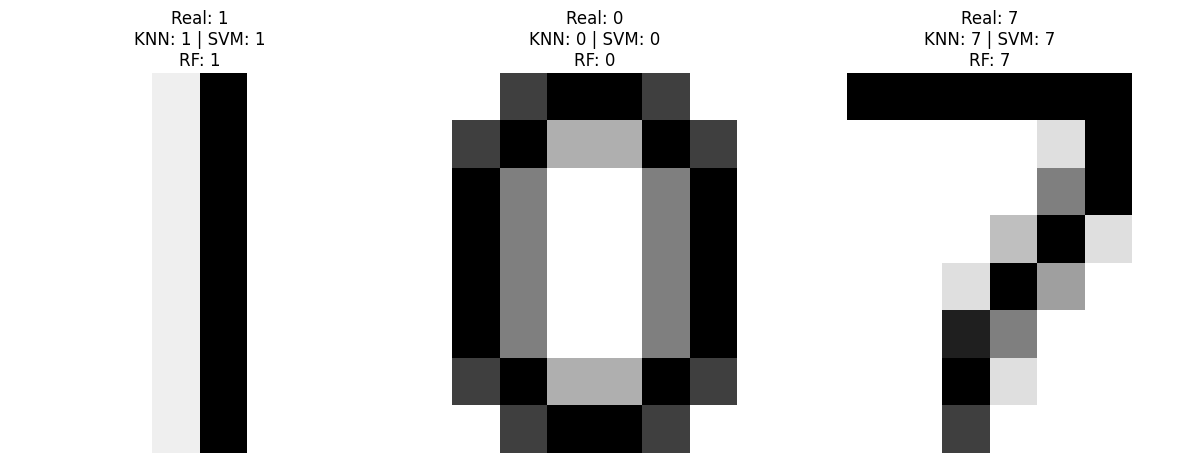

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for i, img in enumerate(mis_digitos):
    # Aplanar imagen para el modelo
    img_flat = img.reshape(1, -1)

    # Obtener predicciones
    p_knn = models["KNN (k=5)"].predict(img_flat)[0]
    p_svm = models["SVM (RBF)"].predict(img_flat)[0]
    p_rf = models["Random Forest"].predict(img_flat)[0]

    # Mostrar imagen
    axes[i].imshow(img, cmap=plt.cm.gray_r)
    titulo = f"Real: {etiquetas_reales[i]}\nKNN: {p_knn} | SVM: {p_svm}\nRF: {p_rf}"
    axes[i].set_title(titulo)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Conclusión: Clasificación de Dígitos Manuscritos
1. Modelo con mejor desempeño
Después de correr los tres modelos, pude observar que SVM (con kernel RBF) y KNN fueron los más exactos, ambos empatando con un 98.61% de exactitud. Aunque los dos fallaron en algunas cosas, el reporte de clasificación muestra que el SVM es un poco más equilibrado al reconocer los números del 0 al 9. Por otro lado, el Random Forest fue el que menos precisión tuvo (97.22%), aunque sigue siendo un número bastante alto para un primer entrenamiento.

2. Dificultades encontradas
Lo que más se me complicó fue dibujar los números con código. No es lo mismo escribir un número en papel que intentar darle forma en una matriz de 8x8 píxeles usando coordenadas y números (del 0 al 16). Fue difícil calcular dónde poner los píxeles más oscuros para que el modelo no se confundiera, ya que en una cuadrícula tan pequeña, cualquier punto que pongas de más cambia mucho la forma del dígito.

3. Observaciones sobre los errores
Me di cuenta de que los modelos no son "adivinos". Por ejemplo, mi dígito 0 lo confundieron con un 3 o un 5. Esto pasó porque mi dibujo quedó muy cuadrado y con líneas muy marcadas, mientras que los números con los que el modelo aprendió (el dataset de Scikit-learn) son más redondeados y borrosos.
